In [2]:
import re
import json
import matplotlib.pyplot as plt
import dataclasses
import os
import numpy as np

In [9]:
BASIC_LOG_PATTERN = re.compile(
    r"EvaluationResult\(seed=(\d+),\s+"
    r"cumulative_reward=([\d.]+),\s+"
    r"time_within_radius=([\d.]+),\s+"
    r"out_of_power=(\w+),\s+"
    r"(?:\w+=\w+,\s+)*"  # <- This is the optional part
    r"final_timestep=(\d+)\)"
)
SAFETY_LAYER_PATTERNS = [
    r'Power safety layer violations: (\d+)',
    r'Execution time: ([\d.]+)',
    r'Altitude safety layer violations: (\d+)',
    r'Envelope safety layer violations: (\d+)'
]

@dataclasses.dataclass
class EvalResult:
    reward: float
    twr: float
    out_of_power: bool
    final_timestep: int
    power_safety_layer_violations: int = 0
    altitude_safety_layer_violations: int = 0
    envelope_safety_layer_violations: int = 0
    execution_time: float = 0.0
    adjusted_twr: float = 0.0


def get_metrics_from_output(filepath):
    rewards = {}
    last_seed = None
    with open(filepath, "r") as f:
        for line in f:
            regex_match = BASIC_LOG_PATTERN.search(line)
            
            # read the basic log data
            if regex_match:
                seed, cumulative_reward, time_within_radius, out_of_power, final_timestep = regex_match.groups()

                seed = int(seed)
                result = EvalResult(float(cumulative_reward), float(time_within_radius), out_of_power=="True", float(final_timestep))
                result.adjusted_twr = result.twr * result.final_timestep / 960
                rewards[seed] = result
                last_seed = seed

            # check for safety layer violations
            elif last_seed is not None:
                for pattern in SAFETY_LAYER_PATTERNS:
                    match = re.search(pattern, line)
                    if match:
                        violation_count = match.group(1)
                        if "Power" in pattern:
                            rewards[last_seed].power_safety_layer_violations = int(violation_count)
                        elif "Execution" in pattern:
                            rewards[last_seed].execution_time = float(violation_count)
                        elif "Altitude" in pattern:
                            rewards[last_seed].altitude_safety_layer_violations = int(violation_count)
                        elif "Envelope" in pattern:
                            rewards[last_seed].envelope_safety_layer_violations = int(violation_count)
    return rewards

def get_metrics_from_outputs(filepaths):
    all_rewards = {}
    for filepath in filepaths:
        rewards = get_metrics_from_output(filepath)
        for seed, result in rewards.items():
            all_rewards[seed] = result
    return all_rewards

def get_saved_result(foldername, results_dir='saved_results'):
    filepath = os.path.join(results_dir, foldername)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Directory {filepath} does not exist.")
    
    # Get all filenames in the filepath
    filenames = [f for f in os.listdir(filepath) if os.path.isfile(os.path.join(filepath, f))]

    # get metrics from files    
    metrics = get_metrics_from_outputs([os.path.join(filepath, filename) for filename in filenames if filename.endswith('.err')])

    # find description.txt file if it exists
    description_file = os.path.join(filepath, 'description.txt')
    if os.path.isfile(description_file):
        with open(description_file, 'r') as f:
            description = f.read()
    else:
        description = "No description file found."
    
    return description, metrics



In [10]:
saved_results = {}

In [11]:
results_dict = {
    # 'jobs/experiments/wind_model/gp_grid': ['gk', 'static'],
    # 'jobs/experiments/wind_model': ['gp_column', 'column'],
    # 'jobs/experiments/num_initializations/gp': ['n1', 'n5', 'n25', 'n250'],
    # 'jobs/experiments/model_fidelity/gp': ['lower', 'low', 'lowest', 'none'],
    # '/share/dean/tmp/ble_runs/gp': [ 'replan/12', 'replan/192', 'replan/48', 'replan/96', 'replan/6', 'replan/192', 'horizon/120', 'horizon/15', 'horizon/240', 'horizon/30', 'horizon/480', 'horizon/60' ],
    'jobs/experiments': ['default'],
    # 'jobs/no_wind_noise_experiments': ['column/horizon/60','column/horizon/120','column/horizon/240','column/horizon/480','column/replan/24','column/replan/48','column/replan/96','column/replan/240'] + 
    #     ['grid/horizon/60','grid/horizon/120','grid/horizon/240','grid/horizon/480','grid/replan/24','grid/replan/48','grid/replan/96','grid/replan/240']
#     'jobs/noise_scale_experiments': ['gp_column/0.00', 'gp_column/0.50', 'gp_column/1.00','gp_column/1.50','gp_column/2.00','gp_column/2.50', 'gp_column/3.00','gp_column/3.50', 'gp_column/4.00','gp_column/4.50', 'gp_column/5.00', 'gp_column/5.50', 'gp_column/6.00', 'gp_column/6.50', 'gp_column/7.00', 'gp_column/7.50', 'gp_column/8.00', 'gp_column/8.50', 'gp_column/9.00', 'gp_column/9.50', 'gp_column/10.00'] + 
# ['perciatelli/0.00', 'perciatelli/0.50','perciatelli/1.00','perciatelli/1.50','perciatelli/2.00','perciatelli/2.50', 'perciatelli/3.00', 'perciatelli/3.50', 'perciatelli/4.00', 'perciatelli/4.50', 'perciatelli/5.00', 'perciatelli/5.50','perciatelli/6.00', 'perciatelli/6.50', 'perciatelli/7.00', 'perciatelli/7.50', 'perciatelli/8.00', 'perciatelli/8.50', 'perciatelli/9.00', 'perciatelli/9.50', 'perciatelli/10.00'] +
#  ['corrected_gp/perciatelli', 'corrected_gp/gp_column']
    'jobs/mppi_experiments': ['base2', 'base','base1'] #'gpu', 'base1']
}

for results_dir, results_names in results_dict.items():
    for result_name in results_names:
        # if result_name in saved_results: continue
        description, metrics = get_saved_result(result_name, results_dir=results_dir)
        description = description.replace('\n', ' ; ')

        print(f"Description for {result_name}: {description}, ({len(metrics)} seeds)")
        saved_results[result_name] = metrics


Description for default: No description file found., (10000 seeds)
Description for base2: No description file found., (831 seeds)
Description for base: No description file found., (1000 seeds)
Description for base1: No description file found., (1000 seeds)


In [30]:
import pandas as pd

def result_name_to_file_name(name: str):
    # if name == 'none':
    #     return f'fidelity-none' 
    # if name.startswith('lo'):
    #     return f'fidelity-{name}'
    # if name.startswith('n'):
    #     return f'initializations-{result_name[1:]}' 
    # if name.startswith('re') or name.startswith('ho'):
    #     return name.replace('/', '-')
    # if name == 'default':
    #     return name

    # if name == 'gk' or name == 'static':
    #     name = f'grid-{name}'
    # return f"wind-{name.replace('_', '-')}"
    if name == "base":
        return 'mppi'
    if name.startswith('perciatelli') or name.startswith('gp_column'):
        return name.replace('/', '_noise_scale=')
    return name

results_to_save = sum(results_dict.values(), [])
for result_name in results_to_save:
    metrics = dict(sorted(saved_results[result_name].items()))
    rewards = [result.reward for result in metrics.values()]
    twrs = [result.twr for result in metrics.values()]
    out_of_power_counts = sum(1 for result in metrics.values() if result.out_of_power)
    power_violations = [result.power_safety_layer_violations for result in metrics.values()]
    altitude_violations = [result.altitude_safety_layer_violations for result in metrics.values()]
    envelope_violations = [result.envelope_safety_layer_violations for result in metrics.values()]
    execution_times = [result.execution_time for result in metrics.values()]
    df = pd.DataFrame({
        "Reward": rewards,
        "Time Within Radius": twrs,
        "Power Safety Layer Violations": power_violations,
        "Altitude Safety Layer Violations": altitude_violations,
        "Envelope Safety Layer Violations": envelope_violations,
        "Execution Time": execution_times
    })
    safe_result_name = result_name_to_file_name(result_name)

    df.index = metrics.keys()
    df.to_csv(f"./results/{safe_result_name}_metrics.csv")



In [15]:
def get_common_seeds(metrics):
    common_seeds = None
    for result in metrics:
        if common_seeds is None:
            common_seeds = set(result.keys())
        else:
            common_seeds.intersection_update(set(result.keys()))
    return common_seeds

def get_average_metrics(metrics):
    """ 
    for each metric, computes the averages and confidence interval over the seeds shared by all the metrics

    returns (seeds used, list of EvalResult objects containing average, list of EvalResult objects containing confidence intervals)
    """

    seeds = get_common_seeds(metrics)

    report = []
    ci = []
    for metric in metrics:
        avg_reward = np.mean([metric[seed].reward for seed in seeds])
        avg_twr = np.mean([metric[seed].twr for seed in seeds])
        avg_out_of_power = np.mean([metric[seed].out_of_power for seed in seeds])
        avg_final_timestep = np.mean([metric[seed].final_timestep for seed in seeds])
        avg_power_safety_layer_violations = np.mean([metric[seed].power_safety_layer_violations for seed in seeds])
        avg_altitude_safety_layer_violations = np.mean([metric[seed].altitude_safety_layer_violations for seed in seeds])
        avg_envelope_safety_layer_violations = np.mean([metric[seed].envelope_safety_layer_violations for seed in seeds])
        avg_execution_time = np.mean([metric[seed].execution_time for seed in seeds])
        avg_adjusted_twr = np.mean([metric[seed].adjusted_twr for seed in seeds])

        # Compute 95% confidence intervals
        avg_reward_ci = 1.96 * np.std([metric[seed].reward for seed in seeds]) / np.sqrt(len(seeds))
        avg_twr_ci = 1.96 * np.std([metric[seed].twr for seed in seeds]) / np.sqrt(len(seeds))
        avg_out_of_power_ci = 1.96 * np.std([metric[seed].out_of_power for seed in seeds]) / np.sqrt(len(seeds))
        avg_final_timestep_ci = 1.96 * np.std([metric[seed].final_timestep for seed in seeds]) / np.sqrt(len(seeds))
        avg_power_safety_layer_violations_ci = 1.96 * np.std([metric[seed].power_safety_layer_violations for seed in seeds]) / np.sqrt(len(seeds))
        avg_altitude_safety_layer_violations_ci = 1.96 * np.std([metric[seed].altitude_safety_layer_violations for seed in seeds]) / np.sqrt(len(seeds))
        avg_envelope_safety_layer_violations_ci = 1.96 * np.std([metric[seed].envelope_safety_layer_violations for seed in seeds]) / np.sqrt(len(seeds))
        avg_execution_time_ci = 1.96 * np.std([metric[seed].execution_time for seed in seeds]) / np.sqrt(len(seeds))
        avg_adjusted_twr_ci = 1.96 * np.std([metric[seed].adjusted_twr for seed in seeds]) / np.sqrt(len(seeds))

        report.append(EvalResult(
            reward=avg_reward,
            twr=avg_twr,
            out_of_power=avg_out_of_power,
            final_timestep=avg_final_timestep,
            power_safety_layer_violations=avg_power_safety_layer_violations,
            altitude_safety_layer_violations=avg_altitude_safety_layer_violations,
            envelope_safety_layer_violations=avg_envelope_safety_layer_violations,
            execution_time=avg_execution_time,
            adjusted_twr = avg_adjusted_twr
        ))

        ci.append(EvalResult(
            reward=avg_reward_ci,
            twr=avg_twr_ci,
            out_of_power=avg_out_of_power_ci,
            final_timestep=avg_final_timestep_ci,
            power_safety_layer_violations=avg_power_safety_layer_violations_ci,
            altitude_safety_layer_violations=avg_altitude_safety_layer_violations_ci,
            envelope_safety_layer_violations=avg_envelope_safety_layer_violations_ci,
            execution_time=avg_execution_time_ci,
            adjusted_twr=avg_adjusted_twr_ci
        ))
        
    return seeds, report, ci

def get_metrics(metrics):
    """
    for each metric, compiles the shared seeds into an array and returns inside Evalresult object

    returns (seeds used, list of EvalResult objects containing the metrics)
    """
    seeds = get_common_seeds(metrics)

    report = []
    for metric in metrics:
        # create numpy arrays for each metric
        rewards = np.array([metric[seed].reward for seed in seeds])
        twr = np.array([metric[seed].twr for seed in seeds])
        out_of_power = np.array([metric[seed].out_of_power for seed in seeds])
        final_timestep = np.array([metric[seed].final_timestep for seed in seeds])
        power_safety_layer_violations = np.array([metric[seed].power_safety_layer_violations for seed in seeds])
        altitude_safety_layer_violations = np.array([metric[seed].altitude_safety_layer_violations for seed in seeds])
        envelope_safety_layer_violations = np.array([metric[seed].envelope_safety_layer_violations for seed in seeds])
        execution_time = np.array([metric[seed].execution_time for seed in seeds])

        report.append(EvalResult(
            reward=rewards,
            twr=twr,
            out_of_power=out_of_power,
            final_timestep=final_timestep,
            power_safety_layer_violations=power_safety_layer_violations,
            altitude_safety_layer_violations=altitude_safety_layer_violations,
            envelope_safety_layer_violations=envelope_safety_layer_violations,
            execution_time=execution_time
        ))
    return seeds, report

In [ ]:
def compare_metrics(result_names):
    seeds, report, ci = get_average_metrics([ saved_results[result_name] for result_name in result_names ])
    print("Averages on", len(seeds), "common seeds")
    for i, (result, ci) in enumerate(zip(report, ci)):
        print(f"Results for {result_names[i]}:")
        print(f"  Reward: {result.reward} ± {ci.reward}")
        print(f"  Time within radius: {result.twr} ± {ci.twr}")
        print(f"  Adjusted TWR: {result.adjusted_twr}± {ci.twr}")
        print(f"  Out of power: {result.out_of_power} ± {ci.out_of_power}")
        print(f"  Final timestep: {result.final_timestep} ± {ci.final_timestep}")
        print(f"  Execution time: {result.execution_time} ± {ci.execution_time}")
        print(f"  Power safety layer violations: {result.power_safety_layer_violations} ± {ci.power_safety_layer_violations}")
        print(f"  Altitude safety layer violations: {result.altitude_safety_layer_violations} ± {ci.altitude_safety_layer_violations}")
        print(f"  Envelope safety layer violations: {result.envelope_safety_layer_violations} ± {ci.envelope_safety_layer_violations}")



In [14]:
compare_metrics(['default'])

Averages on 10000 common seeds
Results for default:
  Reward: 513.2727205974561 ± 5.355104360035146
  Time within radius: 0.39429381006416603 ± 0.006484390161060526
  Adjusted TWR: 0.3942070654259519
  Out of power: 0.0 ± 0.0
  Final timestep: 959.7888 ± 0.11681270241788605
  Execution time: 126.1856555926 ± 0.3550556583335767
  Power safety layer violations: 8.7033 ± 0.5452727288736321
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0


In [ ]:
compare_metrics([ 'corrected_gp/perciatelli', 'perciatelli/10.00' , 'corrected_gp/gp_column', 'gp_column/10.00'])#, 'corrected_gp/gp_column'])

Averages on 98 common seeds
Results for corrected_gp/perciatelli:
  Reward: 501.83833169307786 ± 48.19645564120033
  Time within radius: 0.42628613945578236 ± 0.0525268763961967
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 0.0 ± 0.0
  Power safety layer violations: 13.153061224489797 ± 7.5368084513707165
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for perciatelli/10.00:
  Reward: 501.83833169307786 ± 48.19645564120033
  Time within radius: 0.42628613945578236 ± 0.0525268763961967
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 0.0 ± 0.0
  Power safety layer violations: 13.153061224489797 ± 7.5368084513707165
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for corrected_gp/gp_column:
  Reward: 331.5257357772295 ± 32.21349969747267
  Time within radius: 0.184375 ± 0.02785863059468486
  Out of power: 0.0 ± 0.0
  Final timestep: 

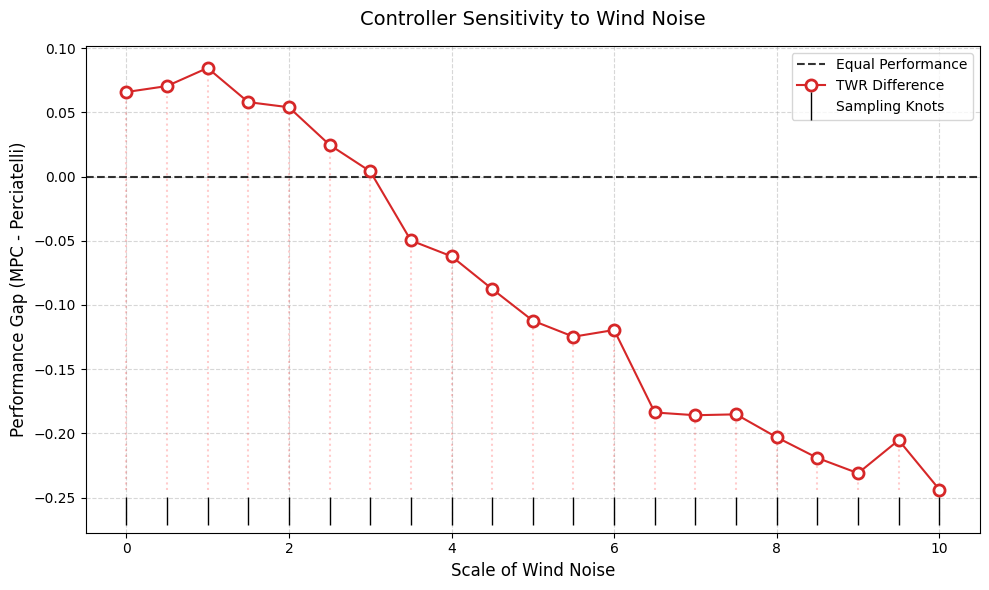

0.06578125000000001
0.07044791666666672
0.08453125
0.057937499999999975
0.05392708333333324
0.02465624999999988
0.003999999999999948
-0.04981250000000004
-0.06213541666666661
-0.08761458333333327
-0.11227083333333343
-0.12473958333333329
-0.11951041666666667
-0.18375000000000002
-0.18589583333333332
-0.18519791666666668
-0.20309374999999996
-0.2191666666666666
-0.2310520833333333
-0.2052916666666667
-0.24373958333333334


In [8]:
mpc_files  = ['gp_column/0.00', 'gp_column/0.50', 'gp_column/1.00','gp_column/1.50','gp_column/2.00','gp_column/2.50', 'gp_column/3.00','gp_column/3.50', 'gp_column/4.00','gp_column/4.50', 'gp_column/5.00', 'gp_column/5.50', 'gp_column/6.00', 'gp_column/6.50', 'gp_column/7.00', 'gp_column/7.50', 'gp_column/8.00', 'gp_column/8.50', 'gp_column/9.00', 'gp_column/9.50', 'gp_column/10.00']
perciatelli_files = ['perciatelli/0.00', 'perciatelli/0.50','perciatelli/1.00','perciatelli/1.50','perciatelli/2.00','perciatelli/2.50', 'perciatelli/3.00', 'perciatelli/3.50', 'perciatelli/4.00', 'perciatelli/4.50', 'perciatelli/5.00', 'perciatelli/5.50','perciatelli/6.00', 'perciatelli/6.50', 'perciatelli/7.00', 'perciatelli/7.50', 'perciatelli/8.00', 'perciatelli/8.50', 'perciatelli/9.00', 'perciatelli/9.50', 'perciatelli/10.00']

_, mpc_reports, mpc_cis = get_average_metrics([ saved_results[mpc_file] for mpc_file in mpc_files ])
_, perciatelli_reports, perciatelli_cis = get_average_metrics([ saved_results[perciatelli_file] for perciatelli_file in perciatelli_files ])

mpc_twr = np.array([ mpc_report.twr for mpc_report in mpc_reports ])
perciatelli_twr = np.array([ perciatelli_report.twr for perciatelli_report in perciatelli_reports ])

values = [0.0, 0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50, 4.0, 4.5, 5.0, 5.5, 6.0, 6.50, 7.00, 7.50, 8.00, 8.50, 9.00, 9.50, 10.00]
diff = (mpc_twr - perciatelli_twr)[:len(values)]

plt.figure(figsize=(10, 6))

# 1. Zero-line representing equal performance
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Equal Performance', alpha=0.8)

# 2. Plot the actual data with markers
plt.plot(values, diff, '-o', color='#d62728', label='TWR Difference', 
         markersize=8, markerfacecolor='white', markeredgewidth=2)

# 3. Vertical markers to highlight the 'Knots'
plt.vlines(values, ymin=min(min(diff), -0.1), ymax=diff, 
           colors='red', linestyles=':', alpha=0.2)

# Styling the X-axis for Wind Noise
plt.title("Controller Sensitivity to Wind Noise", fontsize=14, pad=15)
plt.xlabel("Scale of Wind Noise", fontsize=12)
plt.ylabel("Performance Gap (MPC - Perciatelli)", fontsize=12)

# Better grid for reading values
plt.grid(True, which='major', axis='both', linestyle='--', alpha=0.5)

# Adding the rug plot at the bottom to show sampling density
plt.plot(values, [plt.ylim()[0]] * len(values), '|', color='black', 
         markersize=20, label='Sampling Knots')

plt.legend(frameon=True, loc='best')
plt.tight_layout()
plt.show()
for mpc_report, perciatelli_report in zip(mpc_reports, perciatelli_reports):
    print(mpc_report.twr - perciatelli_report.twr)

In [35]:
to_compare = ['default', 'base']
compare_metrics(to_compare)
mpc_results = get_metrics([ saved_results['default']])[1][0]
mppi_results = get_metrics([ saved_results['base'] ])[1][0]


print([ (seed, ft) for seed, ft in enumerate(mpc_results.final_timestep) if ft < 960])

# indices_to_compare = np.where(mppi_results.out_of_power == False)
# mpc_results.twr[indices_to_compare].mean() - mppi_results.twr[indices_to_compare].mean()

Averages on 1000 common seeds
Results for default:
  Reward: 491.9735714796669 ± 16.849817081762566
  Time within radius: 0.370996875 ± 0.020157279394332085
  Out of power: 0.0 ± 0.0
  Final timestep: 959.836 ± 0.3212792397998975
  Execution time: 126.666835781 ± 1.2166556208155652
  Power safety layer violations: 10.152 ± 1.815572551145671
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for base:
  Reward: 428.7290101058201 ± 16.22614020630419
  Time within radius: 0.30863716972875743 ± 0.018733970890186247
  Out of power: 0.092 ± 0.01791401400021782
  Final timestep: 924.846 ± 8.06222176463873
  Execution time: 85.770722227 ± 0.7250380443374838
  Power safety layer violations: 0.0 ± 0.0
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
[(668, 796.0), (1163, 716.0), (1407, 944.0), (1416, 827.0), (1940, 843.0), (2571, 720.0), (2942, 885.0), (3424, 848.0), (3609, 694.0), (5295, 921.0), (5759, 9

In [26]:
to_compare = ['grid/replan/240','grid/replan/96','grid/replan/48']
to_compare = ['grid/replan/240', 'column/replan/240']
to_compare = ['grid/replan/48', 'column/replan/48']
# to_compare = ['column/replan/240', 'column/replan/48']
# to_compare = ['grid/horizon/60', 'grid/horizon/120', 'grid/horizon/240', 'grid/horizon/480']
compare_metrics(to_compare)
for name in  to_compare:
    print(name, len(saved_results[name]))

KeyError: 'grid/replan/48'

In [ ]:
to_compare = ['n1', 'n5', 'n10', 'n25', 'n50', 'n250']


Averages on 1000 common seeds
Results for n1:
  Reward: 425.450169235341 ± 15.764610958832257
  Time within radius: 0.293671875 ± 0.017993901737780912
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 89.80592306999999 ± 1.272740144423063
  Power safety layer violations: 1.681 ± 0.7261297127527561
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for n5:
  Reward: 445.77438954710016 ± 16.169567803566313
  Time within radius: 0.31710416666666663 ± 0.018709237756052488
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 90.29783866599999 ± 1.245752840803419
  Power safety layer violations: 3.819 ± 1.0712439825466464
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for n10:
  Reward: 450.5247728328836 ± 16.23824892311701
  Time within radius: 0.3231479166666667 ± 0.01888507285967232
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Exec

In [ ]:
to_compare = [
    # 'column', 
    # 'gp_column', 
    # 'perciatelli-1', 
    'gp_grid/static', 
    'gp_grid/gk'
]
compare_metrics(to_compare)

Averages on 1001 common seeds
Results for gp_grid/static:
  Reward: 495.9101675950262 ± 16.97115739825722
  Time within radius: 0.37643255796421027 ± 0.020317073690951763
  Out of power: 0.0 ± 0.0
  Final timestep: 959.8991008991009 ± 0.15296317505802495
  Execution time: 126.11521144355645 ± 1.2677095016281494
  Power safety layer violations: 8.72027972027972 ± 1.7610578409233706
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for gp_grid/gk:
  Reward: 495.8786191299891 ± 16.84274313127386
  Time within radius: 0.3757448888122287 ± 0.0201628912007403
  Out of power: 0.0 ± 0.0
  Final timestep: 959.7212787212787 ± 0.3575517406082358
  Execution time: 128.98186375224773 ± 1.3275683904863995
  Power safety layer violations: 9.390609390609391 ± 1.8598866080231145
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0


In [ ]:
to_compare = [ 'gp_column',
'replan/192', 'replan/48', 'replan/192',
'horizon/120', 'horizon/15', 'horizon/30', 'horizon/60' ]
for name in to_compare:
    print(name, len(saved_results[name]))
compare_metrics(to_compare)

gp_column 602
replan/192 181
replan/48 86
replan/192 181
horizon/120 97
horizon/15 189
horizon/30 181
horizon/60 132
Averages on 86 common seeds
Results for gp_column:
  Reward: 489.7546857629045 ± 61.232831712512024
  Time within radius: 0.37422480620155035 ± 0.07294799069865716
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 122.92012119767445 ± 4.295822155335783
  Power safety layer violations: 5.476744186046512 ± 4.82094389267815
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for replan/192:
  Reward: 384.1003970504175 ± 51.147298708147886
  Time within radius: 0.24413759689922485 ± 0.05670720853115991
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 20.116791162790694 ± 1.2887095291061175
  Power safety layer violations: 2.5930232558139537 ± 2.8495441632292917
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for replan/48:
  Rew

In [ ]:
to_compare = ['mpc4_agent-0', 'medium', 'default', 'perciatelli-1']
compare_metrics(to_compare)


KeyError: 'medium'

In [ ]:
to_compare = [ f'test{i}' for i in range(1, 16 + 1) ]
compare_metrics(to_compare)
for name in [ f'test{i}' for i in range(1, 6 + 1) ]:
    print(name, len(saved_results[name]))

Averages on 100 common seeds
Results for test1:
  Reward: 434.12391469888 ± 52.3473308735699
  Time within radius: 0.30744791666666665 ± 0.06046974387031352
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 76.85391225000001 ± 2.0195056815594894
  Power safety layer violations: 7.88 ± 5.4600182645848365
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for test2:
  Reward: 424.7448040449249 ± 51.25717282531518
  Time within radius: 0.29587499999999994 ± 0.05903702849024782
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 100.95447999999999 ± 2.5201120172360585
  Power safety layer violations: 5.3 ± 4.514088931334871
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for test3:
  Reward: 448.2200376723857 ± 52.76287789427554
  Time within radius: 0.32601041666666675 ± 0.06086189810368213
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.

In [ ]:
to_compare = [ 'test6', 'n10' ]
compare_metrics(to_compare)

Averages on 100 common seeds
Results for test6:
  Reward: 453.69425858620207 ± 53.56513983192722
  Time within radius: 0.33245833333333336 ± 0.06235302625842095
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 105.5267174 ± 3.1188739031935073
  Power safety layer violations: 1.57 ± 1.4478165911468204
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for n10:
  Reward: 446.1551753220177 ± 53.01808745552032
  Time within radius: 0.32365625000000003 ± 0.06102540843579178
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Execution time: 80.33358987 ± 2.713363541849902
  Power safety layer violations: 1.61 ± 1.9970649579820878
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0


In [ ]:
relevant_mpc_agents = ['mpc4_agent-0', 'mpc4_agent-1','mpc4_agent-2']
compare_metrics(['perciatelli-1', 'distilled_perciatelli_agent-0', 'mpc4_agent-4', 'mpc4_agent-5', 'mpc4_agent-6', 'mpc4_agent-7'])

Averages on 100 common seeds
Results for perciatelli-1:
  Reward: 385.8504184302149 ± 56.203145899300864
  Time within radius: 0.2866041666666667 ± 0.0639733829064327
  Out of power: 0.0 ± 0.0
  Final timestep: 960.0 ± 0.0
  Power safety layer violations: 17.66 ± 7.341408610777636
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0
Results for distilled_perciatelli_agent-0:
  Reward: 136.28089124618026 ± 19.83338319474119
  Time within radius: 0.042585307017543844 ± 0.01571950652843902
  Out of power: 0.01 ± 0.01950175376728975
  Final timestep: 959.9 ± 0.1950175376728975
  Power safety layer violations: 47.7 ± 10.918888917834085
  Altitude safety layer violations: 0.0 ± 0.0
  Envelope safety layer violations: 0.0 ± 0.0


In [ ]:
def bucketize(values, boundaries):
    boundaries = np.array(boundaries)
    indices = np.searchsorted(boundaries, values, side='right')
    buckets = [[] for _ in range(len(boundaries) + 1)]
    for val, idx in zip(values, indices):
        buckets[idx].append(val)
    return buckets

def histogram(values, boundaries):
    buckets = bucketize(values, boundaries)
    bucket_counts = [len(bucket) for bucket in buckets]

    # Use equal-width bars
    n_bins = len(bucket_counts)
    x = np.arange(n_bins)  # positions for equal-width bars

    # Prepare labels: each corresponds to the RIGHT edge of the bin
    right_edges = boundaries
    labels = [f"{boundaries[0]:.2f}"] + [f"{b:.2f}" for b in right_edges[1:]] + [f""]

    # Plot
    plt.figure(figsize=(10, 5))
    bar_width = 1.0
    plt.bar(x, bucket_counts, width=bar_width, edgecolor='black', color='skyblue', align='edge')

    # Ticks at right edges of each bar
    tick_positions = x + bar_width
    plt.xticks(tick_positions, labels, rotation=45, ha='right')

    plt.xlabel("Bucket right boundaries (equal-width bars)")
    plt.ylabel("Frequency")
    plt.title("Histogram-like Bar Plot with Equal Width Bars")
    plt.tight_layout()
    plt.grid(True, axis='y')


In [ ]:
to_compare = ['mpc4_agent-0', 'perciatelli-0']

seeds, reports = get_metrics([ saved_results[saved_result_name] for saved_result_name in to_compare ])

delta_twr_num_buckets_one_side = 10
delta_twr_boundaries = np.concatenate([
    np.linspace(-1.0, 0.0, delta_twr_num_buckets_one_side + 1)[:-1],
    [-1e-8, 1e-8],
    np.linspace(0.0, 1.0, delta_twr_num_buckets_one_side + 1)[1:]])

delta_twr = reports[0].twr - reports[1].twr
histogram(delta_twr, delta_twr_boundaries)
plt.title('mpc_twr - perciatelli_twr')
plt.xlabel('delta twr (right boundaries), equal width bars')
plt.show()



def divide_scores(twr_a, twr_b):
    """ 
    special division for scores 
    
    if both are zero, return 1, but if a solution is found and the twr_b does not find it, this is infinity
    """
    return np.where(
        twr_b == 0.0,
        np.where(twr_a == 0.0, 1.0, np.inf),
        twr_a / twr_b
    )

twr_scores = divide_scores(reports[0].twr, reports[1].twr)

# Create more complicated boundary to handle ratios (special values at 0.0, 1.0, and inf)
num_buckets_lt_1 = 10
num_buckets_btwn_1_and_2 = 10
num_buckets_after_2 = 8
max_score_value_to_plot = 10
epsilon = 1e-8
twr_boundaries = np.concatenate([ [-epsilon, epsilon], 
    np.linspace(0.0, 1.0 - 1e-8, num_buckets_lt_1 + 1)[1:],
    np.linspace(1.0 + epsilon, 2.0, num_buckets_btwn_1_and_2 + 1),
    np.linspace(2.0, max_score_value_to_plot,num_buckets_after_2 + 1 )[1:],
    [np.inf]])

histogram(twr_scores, twr_boundaries)
plt.title('mpc_twr / perciatelli_twr')
plt.xlabel('twr score (right boundaries), equal width bars')
plt.show()